In [21]:
import sys
sys.path.append('/Users/brianlerner/Library/CloudStorage/OneDrive-Personal/Code/cerebra/src')
from server.query import get_schema, get_events
from utils.server import connect_to_collection
from utils.general import to_snake_case
import pandas as pd
import prompts.bio as PROMPTS
import json

In [2]:
collection = connect_to_collection()

Let's walkthrough the logic behind the analysis pipeline.

Let's first consider a user request: `How many days per week have I practice?`

In order to get a response for the user, the following needs to be known for initial data extraction:
- name: practice
- start_date: not specified
- end_date: not specified
- start_time: not specified
- end_time: not specified
<!-- - operation:  -->

The first issue that needs to be overcome is the issue of the label. In order to overcome this, we'll find the current labels available and see what is similar.

In [5]:
schema = get_schema()
variable_names = list(schema.keys())
print("Current variable names:", variable_names)

Current variable names: ['elbow pain', 'Basketball Game', 'Computer Programming', 'Basketball Practice', 'Discrete Mathematics', 'Discrete Mathematics HW due', 'Computer Programming HW due']


In [6]:
from openai import OpenAI
client = OpenAI()

variable_info = {
        # 'name': 'practice'
        'name': 'bball practice'
    }

def get_embedding(text, model="text-embedding-ada-002"):
   text = text.replace("\n", " ")
   return client.embeddings.create(input = [text], model=model).data[0].embedding

def get_closest_variable_names(base_name, variable_names, top_n=-1, threshold=0.05, return_list=True):
    import pandas as pd
    from scipy.spatial.distance import cosine 


    variable_names = [base_name] + variable_names

    df = pd.DataFrame(variable_names, columns=["name"])

    # this will be done beforehand during real model
    df["embeddings"] = df.name.apply(lambda x: get_embedding(x, model='text-embedding-ada-002'))

    df["distances"] = df["embeddings"].apply(lambda x: cosine(x, df.iloc[0]["embeddings"])) 
    df.sort_values(by="distances", inplace=True)

    if threshold > 0:
        df = df[df["distances"] <= threshold]

    df.drop("embeddings", axis=1, inplace=True)
    df = df.iloc[1:]
    if top_n > 0:
        df = df.iloc[0:top_n+1]

    if return_list:
        return list(df.name)
    else:
        return df

closest_variable_names = get_closest_variable_names(variable_info["name"], variable_names, top_n=1, threshold=0.05)

if len(closest_variable_names) == 1:
    closest_variable_name = closest_variable_names[0]
    print("Closest variable name:", closest_variable_name)
elif len(closest_variable_names) > 1:
    print("Multiple variables found. Please select one:", closest_variable_names)
elif len(closest_variable_names) == 0:
    print("No variables found. Please try again.")




Closest variable name: Basketball Practice


Now, let's get events using

In [80]:
conditions = {
    "start_date":None,
    "end_date":None,
    "start_time":None,
    "end_time":None,
    }


def get_events(
    name=None,
    start_date=None, 
    end_date=None, 
    start_time=None,
    end_time=None,
    # cat=None,
    # group=None, 
    profile='llm_v0', 
    print_events=False
    ):
    

    schema = get_schema()
    if name in schema:
        cat = schema[name]
    else:
        print(f'name: {name} not found in schema')
        return []
    # conditions = [
    #                 {"$gte": ["$$event.start_datetime", start_date]},
    #                 {"$lte": ["$$event.start_datetime", end_date]},
    #             ]
    conditions = []
    if start_date:
        conditions.append({"$gte": ["$$event.start_datetime", start_date]})
    if end_date:
        conditions.append({"$lte": ["$$event.start_datetime", end_date]})
    if name:
        conditions.append({"$eq": ["$$event.name", name]})
    # if group:
        # conditions.append({"$eq": ["$$event.group", group]})

    pipeline = [
        {"$match": {"profile_id": profile}},  # Filter to the specific profile
        {"$project": {  # Project only the calendarEvents field
            cat: {
                "$filter": {  # Filter the calendarEvents array
                    "input": f"${cat}",
                    "as": "event",
                    "cond": {  # Condition to check the date range
                        "$and": conditions
                    }
                }
            }
        }}
    ]

    # Execute the aggregation pipeline
    cursor = collection.aggregate(pipeline)
    events_list = [event for event in cursor]

    if print_events:
        # Process and print the results
        for events in events_list:
            # print(events)
            print()
            for event in events.get(cat, []):
                print(event)

    return events_list[0][cat]
def retrieve_events(name, conditions={}):
    conditions["name"] = name
    events = get_events(**conditions)
    return events

events = retrieve_events(closest_variable_name, conditions=conditions)
events

[{'name': 'Basketball Practice',
  'id': 'basketball_practice',
  'group': 'basketball_team',
  'location': 'The K Center',
  'description': 'Practice for the Duke basketball team.',
  'start_datetime': datetime.datetime(2023, 9, 3, 18, 0),
  'end_datetime': datetime.datetime(2023, 9, 3, 20, 0)},
 {'name': 'Basketball Practice',
  'id': 'basketball_practice',
  'group': 'basketball_team',
  'location': 'The K Center',
  'description': 'Practice for the Duke basketball team.',
  'start_datetime': datetime.datetime(2023, 9, 4, 18, 0),
  'end_datetime': datetime.datetime(2023, 9, 4, 20, 0)},
 {'name': 'Basketball Practice',
  'id': 'basketball_practice',
  'group': 'basketball_team',
  'location': 'The K Center',
  'description': 'Practice for the Duke basketball team.',
  'start_datetime': datetime.datetime(2023, 9, 5, 18, 0),
  'end_datetime': datetime.datetime(2023, 9, 5, 20, 0)},
 {'name': 'Basketball Practice',
  'id': 'basketball_practice',
  'group': 'basketball_team',
  'location'

Now, that we have our events, let's answer the original question: how many times do I have the event on average per week.

This entails the following directions:
- "operation": "average"
- "interval" : "week 

In [8]:
df= pd.DataFrame(events)
# Convert start_datetime to datetime
df['start_datetime'] = pd.to_datetime(df['start_datetime'])

# Set start_datetime as index
df.set_index('start_datetime', inplace=True)

# retain a single column for each unique date
df = df[["name"]]


# Resample by week and count the number of events
weekly_event_counts = df.resample('W').count()

# Calculate the average number of events per week
average_events_per_week = weekly_event_counts.mean()

# The average number of events per week
print(average_events_per_week.round(0).astype(int).values[0])

# ADD start_time and end_time to conditions
# ADD start_date and end_date to conditions

5


# Question 2

Now let's consider: `Why do I have elbow pain?`

Now, this is a hard question to answer. The final implementation of this will be a sophisticated agent. For now, it will be a little less sophisticated. It will work like this. 
- extract info from all events (in background, even before query)
- correlate what is needed, and as possible
- call upon the correlations when determining if a relationship exists
It could be structured like this:
{'elbow_pain',
'corr_with':
    'valid':false
    {
        'basketball_game':
            'corr':
                {
                    'value':
                    'method':
                }
            'caus':
                {
                    'value':
                    'method':'LLM'

                }
            'timescale':
                {'D':
                    {
                        'full_range':
                        '+1d':
                        '+2d'
                        ...
                        '
                    }
                'W':
                }
    }
}

In order to get a response for the user, the following needs to be known for initial data extraction:
- elbow_pain (correlation with all other variables)

Let's set about the business of getting proper correlation/causation with all the other variables

The first thing we need to do is determine how to assign relationships with the other variables. Right now, everything we have is a binary variable so it can all be properly compared.
So, what should actually be compared. Well, I think we can start by looking at calendar_events and that nothing should be considered causal with a calendar event

Categories
- calendar_events "Basketball Practice"
    - class,
- unscheduled_events/activities "hiking", "movies with friends"
    - hobbies
    - social 
- symptoms/sensations "elbow pain"
- nutrition "calories"
- scores
    - mood
    - stress
    - energy
    - sleep

1. check if labels exist
2. check if relationships valid
3. perform op
4. institute groups
<!-- Also: add occur variable to each property -->

In [22]:
from openai import OpenAI
from llm.chat import chat_completion_request, Conversation
import prompts.bio as PROMPTS

client = OpenAI()
GPT_MODEL = "gpt-3.5-turbo-1106"
# GPT_MODEL = "gpt-4-1106-preview"
profile = 'llm_v0'
bio = getattr(PROMPTS, profile)



system_prompt = f"""You are a utility that determines the potential causality between two variables. These variables come from an indivdual's life as described in this bio:

{bio}

When the two variables are provided, they will be words or phrases and be comma-separated. Assume that the first variable is the potential cause and the second variable is the potential effect. They
please determine the strength of causality from 1-5, with 1 being the weakest and 5 being the strongest. 
If you are unsure, please say so by outputting a 0.
Also, please provide a short explanation for your answer.
When requested, return the requested information as a JSON object with the keys "causality_score" and "explanation".
"""

# print(system_prompt)
conversation = Conversation(first_message = ("system", system_prompt))
conversation.add_message("user", "Please find the causality between: computer hw due, elbow pain")
response = chat_completion_request(conversation, model=GPT_MODEL, stream=False, response_format={"type":"json_object"})
# response = get_completion(conversation.messages, model=GPT_MODEL,response_format={"type":"json_object"})
full_response = response.choices[0].message.content 
full_response = json.loads(full_response)
print(full_response)

{'causality_score': 3, 'explanation': 'There is a moderate causality between computer homework being due and experiencing elbow pain. The prolonged use of a computer for homework can lead to poor ergonomics and posture, which may contribute to elbow pain.'}


In [63]:
# this may not be usefull..
link_rules = {
        'calendar_events':{
            'datatype': 'binary', # include here?
            'caused': False,
        }
        # 'activities':{
        #     'datatype': 'binary', # include here?
        #     'no_forward_link': ['calendar_events'],
        # }
    }

def get_permutations(variables):

    schema = get_schema()
    def link_filter(x, y):
        # x = cause, y = effect
        if x in schema:
            x_cat = schema[x]
        else:
            raise ValueError(f'{x} not found in schema')
        if y in schema:
            y_cat = schema[y]
        else:
            raise ValueError(f'{y} not found in schema')
        
        if y_cat in link_rules:
            return link_rules[y_cat].get("caused", True)
        else:
            return True

        # if x_cat in link_rules:
        #     if link_rules[x_cat].get("no_backward_link", False):
        #         return False
        # elif y_cat in link_rules:
        #     print(x,y)

        #     if link_rules[y_cat].get("no_forward_link", False):
        #         return False
        # else:
        #     return True

    from itertools import permutations
    # Finding all combinations of two variables where order matters
    permutations = [pair for pair in permutations(variables, 2) if link_filter(*pair)]
    return permutations

permutations = get_permutations(schema.keys())
len(permutations), permutations

(6,
 [('Basketball Game', 'elbow pain'),
  ('Computer Programming', 'elbow pain'),
  ('Basketball Practice', 'elbow pain'),
  ('Discrete Mathematics', 'elbow pain'),
  ('Discrete Mathematics HW due', 'elbow pain'),
  ('Computer Programming HW due', 'elbow pain')])

In [32]:
str(("a", "b"))

"('a', 'b')"

In [38]:
import time
def measure_causality(cause, effect):
    system_prompt = f"""You are a utility that determines the potential causality between two variables. These variables come from an indivdual's life as described in this bio:

    {bio}

    When the two variables are provided, they will be words or phrases and be comma-separated. Assume that the first variable is the potential cause and the second variable is the potential effect. They
    please determine the strength of causality from 1-5, with 1 being the weakest and 5 being the strongest. 
    If you are unsure, please say so by outputting a 0.
    Also, please provide a short explanation for your answer.
    When requested, return the requested information as a JSON object with the keys "causality_score" and "explanation".
    """

    # print(system_prompt)
    conversation = Conversation(first_message = ("system", system_prompt))
    conversation.add_message("user", f"Please find the causality between: {cause}, {effect}")

    start = time.time()
    response = chat_completion_request(conversation, model=GPT_MODEL, stream=False, response_format={"type":"json_object"})
    end = time.time()
    # response = get_completion(conversation.messages, model=GPT_MODEL,response_format={"type":"json_object"})
    json_response = response.choices[0].message.content 

    try:
        full_response = json.loads(json_response)
        if "causality_score" not in full_response:
            causality_score = f"Error: causality_score not found in response. Response: {full_response}"
        else:
            causality_score = full_response["causality_score"]
        if "explanation" not in full_response:
            explanation = f"Error: explanation not found in response. Response: {full_response}"
        else:
            explanation = full_response["explanation"]
    except Exception as e:
        print(e)
        print(json_response)
        causality_score = None
        explanation = e
        runtime=None
    
    return {'causality_score':causality_score, 'explanation':explanation, 'runtime':end-start}


In [65]:
pd.set_option('display.max_colwidth', None)

def create_causality_cols(x):
    c_info = measure_causality(x.cause, x.effect)
    return pd.Series(list(c_info.values()))

perm_df = pd.DataFrame(permutations, columns=["cause", "effect"])#.iloc[0:10]
perm_df[['causality_score', 'explanation', 'runtime']] = perm_df.apply(create_causality_cols, axis=1)
perm_df


,cause,effect,causality_score,explanation,runtime
0,Basketball Game,elbow pain,4,"There is a strong causality between playing basketball games and experiencing elbow pain, as the physical demands of the game, such as shooting, dribbling, and defending, can put strain on the elbow joint and surrounding muscles, potentially leading to pain or injury.",1.650221
1,Computer Programming,elbow pain,3,"There is a moderate strength causality between computer programming and elbow pain. Prolonged computer use and poor ergonomics can lead to repetitive strain injuries, including elbow pain. However, individual factors and behaviors also play a role in the development of elbow pain.",1.525373
2,Basketball Practice,elbow pain,4,"Basketball practice can involve repetitive motions and physical exertion, which can lead to overuse injuries such as elbow pain. The nature of the sport and the strain it puts on the body make it highly likely that basketball practice could cause elbow pain.",1.433934
3,Discrete Mathematics,elbow pain,0,There is no direct causal relationship between studying Discrete Mathematics and experiencing elbow pain. These two variables are unlikely to have a direct impact on each other.,1.126409
4,Discrete Mathematics HW due,elbow pain,3,"There is a moderate causality between Discrete Mathematics HW due and elbow pain. It is possible that the stress of approaching deadlines and prolonged sitting while working on the homework could contribute to the development of elbow pain, especially if the individual is not mindful of their posture.",1.696662
5,Computer Programming HW due,elbow pain,3,"There is a moderate causality between Computer Programming HW due and elbow pain. Prolonged computer use and typing can lead to strain on the elbow and arm muscles, potentially resulting in pain or discomfort.",1.374528


Ok, now time to figure out the correlations.
For now, let's only apply correlation to things that are valid causally.

In [99]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests, ccf
from datetime import datetime, timedelta

# Example list of dictionaries
events = x_events+ y_events

# Convert to DataFrame
df = pd.DataFrame(events)
df = df[['name','start_datetime', 'end_datetime']]
df

,name,start_datetime,end_datetime
0,Basketball Game,2023-09-01 19:00:00,2023-09-01 22:00:00
1,Basketball Game,2023-09-08 19:00:00,2023-09-08 22:00:00
2,Basketball Game,2023-09-15 19:00:00,2023-09-15 22:00:00
3,Basketball Game,2023-09-22 19:00:00,2023-09-22 22:00:00
4,Basketball Game,2023-09-29 19:00:00,2023-09-29 22:00:00
5,Basketball Game,2023-10-06 19:00:00,2023-10-06 22:00:00
6,Basketball Game,2023-10-13 19:00:00,2023-10-13 22:00:00
7,Basketball Game,2023-10-20 19:00:00,2023-10-20 22:00:00
8,Basketball Game,2023-10-27 19:00:00,2023-10-27 22:00:00
9,Basketball Game,2023-11-03 19:00:00,2023-11-03 22:00:00



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2820  , p=0.5955  , df_denom=2856, df_num=1
ssr based chi2 test:   chi2=0.2822  , p=0.5952  , df=1
likelihood ratio test: chi2=0.2822  , p=0.5952  , df=1
parameter F test:         F=0.2820  , p=0.5955  , df_denom=2856, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2028  , p=0.8165  , df_denom=2853, df_num=2
ssr based chi2 test:   chi2=0.4063  , p=0.8162  , df=2
likelihood ratio test: chi2=0.4063  , p=0.8162  , df=2
parameter F test:         F=0.2028  , p=0.8165  , df_denom=2853, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2077  , p=0.8911  , df_denom=2850, df_num=3
ssr based chi2 test:   chi2=0.6247  , p=0.8907  , df=3
likelihood ratio test: chi2=0.6247  , p=0.8908  , df=3
parameter F test:         F=0.2077  , p=0.8911  , df_denom=2850, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.2634  , p=0.

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3919270926.py:33: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



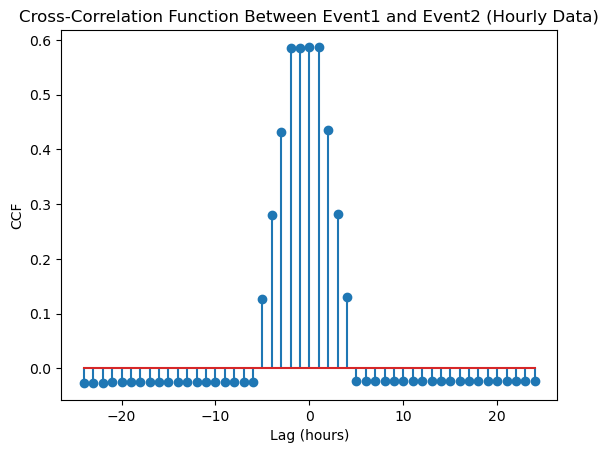

In [143]:

names = df.name.unique()

# Convert datetime strings to datetime objects
df['start_datetime'] = pd.to_datetime(df['start_datetime'])
df['end_datetime'] = pd.to_datetime(df['end_datetime'])

# Resample to a consistent time interval (e.g., hourly)
start = df['start_datetime'].min().floor('H')
end = df['end_datetime'].max().ceil('H')
time_index = pd.date_range(start=start, end=end, freq='H')

# Create time series for each event type
series_a = pd.Series(0, index=time_index)
series_b = pd.Series(0, index=time_index)

# Populate the series based on events
for _, row in df.iterrows():
    if row['name'] == names[0]:
        series_a[row['start_datetime']:row['end_datetime']] = 1
    elif row['name'] == names[1]:
        series_b[row['start_datetime']:row['end_datetime']] = 1

# Ensure same length
length = min(len(series_a), len(series_b))
series_a = series_a[:length]
series_b = series_b[:length]

maxlag = 24
# Granger Causality Test
gc_result = grangercausalitytests(pd.DataFrame({names[0]: series_a, names[1]: series_b}), maxlag=maxlag)

# Cross-Correlation Function
ccf_vals = ccf(series_a, series_b, unbiased=True)

# # Print CCF results (example for first 10 lags)
# print("CCF Results (first 10 lags):")
# for lag in range(10):
#     print(f"Lag {lag}: {ccf_result[lag]}")

# # Granger Causality Test
# max_lag_hrs = 12 # Define max lag (days)
# gc_test = grangercausalitytests(pd.concat([df_event1, df_event2], axis=1), maxlag=max_lag_hrs)

# # Assuming df_event1 and df_event2 are resampled to hourly data

# # max_lag_hours = 24  # Define max lag in hours
lags = range(-maxlag, maxlag + 1)


# ccf_vals = ccf(df_event1, df_event2, unbiased=True)



# Make sure that the length of 'lags' and 'ccf_vals' is the same
min_length = min(len(lags), len(ccf_vals))
lags = lags[:min_length]
ccf_vals = ccf_vals[:min_length]

# Plotting the CCF
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Event1 and Event2 (Hourly Data)')
plt.xlabel('Lag (hours)')
plt.ylabel('CCF')
plt.show()




In [140]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests, ccf
import matplotlib.pyplot as plt


df['start_datetime'] = pd.to_datetime(df['start_datetime'])
df['date'] = df['start_datetime'].dt.date

# Create time series for each event
df_event1 = df[df['name'] == names[0]].groupby('date').size().reindex(pd.date_range(df['date'].min(), df['date'].max(), freq='H'), fill_value=0)
df_event2 = df[df['name'] == names[1]].groupby('date').size().reindex(pd.date_range(df['date'].min(), df['date'].max(), freq='H'), fill_value=0)


In [113]:
df_event1.shape

(2857,)

In [121]:
df

,name,start_datetime,end_datetime,date
0,Basketball Game,2023-09-01 19:00:00,2023-09-01 22:00:00,2023-09-01
1,Basketball Game,2023-09-08 19:00:00,2023-09-08 22:00:00,2023-09-08
2,Basketball Game,2023-09-15 19:00:00,2023-09-15 22:00:00,2023-09-15
3,Basketball Game,2023-09-22 19:00:00,2023-09-22 22:00:00,2023-09-22
4,Basketball Game,2023-09-29 19:00:00,2023-09-29 22:00:00,2023-09-29
5,Basketball Game,2023-10-06 19:00:00,2023-10-06 22:00:00,2023-10-06
6,Basketball Game,2023-10-13 19:00:00,2023-10-13 22:00:00,2023-10-13
7,Basketball Game,2023-10-20 19:00:00,2023-10-20 22:00:00,2023-10-20
8,Basketball Game,2023-10-27 19:00:00,2023-10-27 22:00:00,2023-10-27
9,Basketball Game,2023-11-03 19:00:00,2023-11-03 22:00:00,2023-11-03



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0669  , p=0.7960  , df_denom=2853, df_num=1
ssr based chi2 test:   chi2=0.0669  , p=0.7959  , df=1
likelihood ratio test: chi2=0.0669  , p=0.7959  , df=1
parameter F test:         F=0.0669  , p=0.7960  , df_denom=2853, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0679  , p=0.9344  , df_denom=2850, df_num=2
ssr based chi2 test:   chi2=0.1360  , p=0.9343  , df=2
likelihood ratio test: chi2=0.1360  , p=0.9343  , df=2
parameter F test:         F=0.0679  , p=0.9344  , df_denom=2850, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0689  , p=0.9765  , df_denom=2847, df_num=3
ssr based chi2 test:   chi2=0.2072  , p=0.9764  , df=3
likelihood ratio test: chi2=0.2072  , p=0.9764  , df=3
parameter F test:         F=0.0689  , p=0.9765  , df_denom=2847, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.0700  , p=0.

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/4124203833.py:10: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



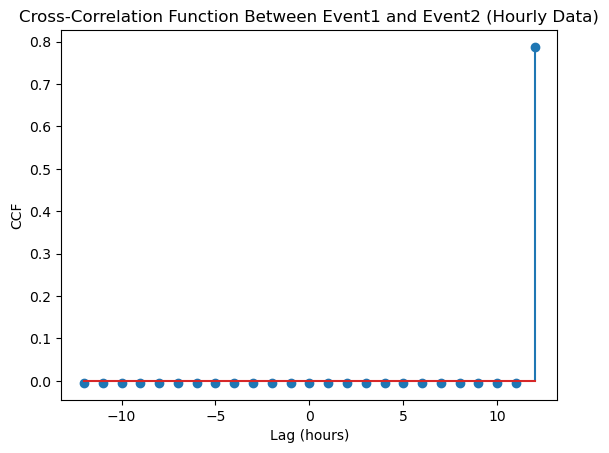

In [122]:
# Granger Causality Test
max_lag_hrs = 12 # Define max lag (days)
gc_test = grangercausalitytests(pd.concat([df_event1, df_event2], axis=1), maxlag=max_lag_hrs)

# Assuming df_event1 and df_event2 are resampled to hourly data

# max_lag_hours = 24  # Define max lag in hours
lags = range(-max_lag_hrs, max_lag_hrs + 1)

ccf_vals = ccf(df_event1, df_event2, unbiased=True)

# Make sure that the length of 'lags' and 'ccf_vals' is the same
min_length = min(len(lags), len(ccf_vals))
lags = lags[:min_length]
ccf_vals = ccf_vals[:min_length]

# Plotting the CCF
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Event1 and Event2 (Hourly Data)')
plt.xlabel('Lag (hours)')
plt.ylabel('CCF')
plt.show()



In [133]:
for i in df_event1:
    print(i)

1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [125]:
df_event2[df_event2 > 0]

2023-09-14    1
2023-09-28    1
2023-10-05    1
2023-10-19    1
2023-10-26    1
2023-11-02    1
2023-11-09    1
2023-11-30    1
2023-12-07    1
2023-12-14    1
2023-12-28    1
dtype: int64

range(-7, 8)

In [118]:
# Cross-Correlation Function
lags = range(-max_lag, max_lag + 1)
ccf_vals = ccf(df_event1, df_event2, unbiased=True)
ccf_vals.shape


/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3082671451.py:3: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



(2857,)

In [ ]:

# Plotting the CCF
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Event1 and Event2')
plt.xlabel('Lag (days)')
plt.ylabel('CCF')
plt.show()


# CCF

/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/140677489.py:13: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



ValueError: could not broadcast input array from shape (217,) into shape (20,)

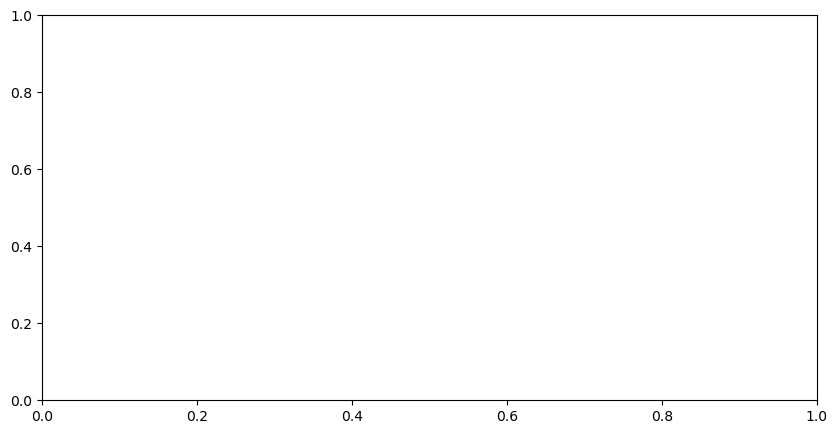

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

# Generate sample data
np.random.seed(0)  # For reproducibility
hours = pd.date_range(start='2021-01-01', end='2021-01-10', freq='H')
series_A = np.random.rand(len(hours))  # Random data for Series A
series_B = np.roll(series_A, shift=3)  # Series B is Series A shifted by 3 hours

# Apply CCF
ccf_vals = ccf(series_A, series_B, unbiased=True)


max_lag = 10
# Plotting the CCF
lags = range(-max_lag, max_lag)
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_vals)
plt.title('Cross-Correlation Function Between Series A and B')
plt.xlabel('Lag (hours)')
plt.ylabel('CCF')
plt.xlim(-48, 48)  # Limiting x-axis to +/- 48 hours for clarity
plt.show()


/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3768808779.py:11: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



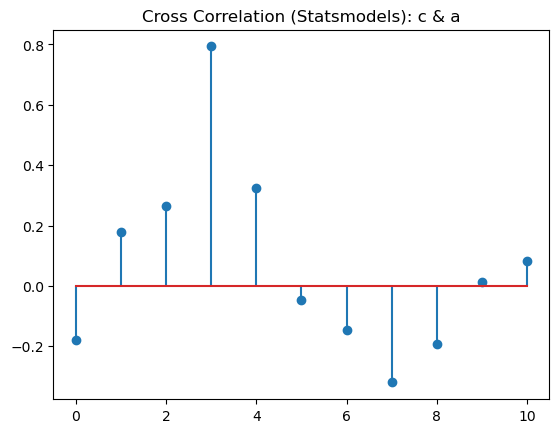

In [152]:
points = 50
a = np.random.rand(points)
b = np.random.rand(points)
data = pd.DataFrame({"a":a, "b": b})
data["c"] = data["a"].shift(3) + data["b"].shift(1)
data.shape, data.columns
data.dropna(inplace=True)


/var/folders/s3/ksgg4wnd1cgccsdh_8yrw02h0000gn/T/ipykernel_37506/3819410628.py:3: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



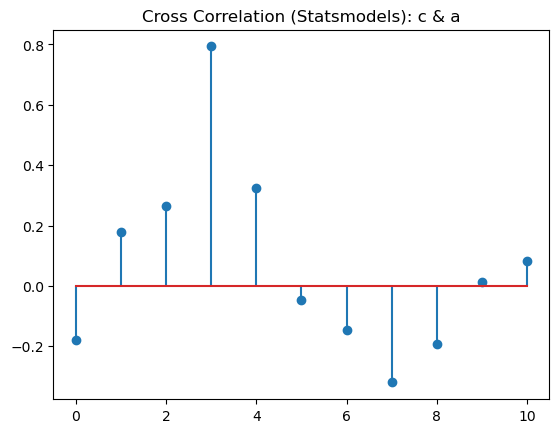

In [153]:

def plot_ccf_sm(target, exog, unbiased=False, nlags=10):
    """Plot CCF using Statsmodels"""
    ccfs = ccf(target, exog, unbiased=False)[:nlags+1]
    lags = np.arange(len(ccfs))[:nlags+1]
    _ = plt.stem(lags, ccfs)
    _ = plt.title(f"Cross Correlation (Statsmodels): {target.name} & {exog.name}")

plot_ccf_sm(data["c"], data["a"])

# Old

In [66]:
causal_threshold = 3
causal_df = perm_df[perm_df.causality_score >= causal_threshold]
causal_df

,cause,effect,causality_score,explanation,runtime
0,Basketball Game,elbow pain,4,"There is a strong causality between playing basketball games and experiencing elbow pain, as the physical demands of the game, such as shooting, dribbling, and defending, can put strain on the elbow joint and surrounding muscles, potentially leading to pain or injury.",1.650221
1,Computer Programming,elbow pain,3,"There is a moderate strength causality between computer programming and elbow pain. Prolonged computer use and poor ergonomics can lead to repetitive strain injuries, including elbow pain. However, individual factors and behaviors also play a role in the development of elbow pain.",1.525373
2,Basketball Practice,elbow pain,4,"Basketball practice can involve repetitive motions and physical exertion, which can lead to overuse injuries such as elbow pain. The nature of the sport and the strain it puts on the body make it highly likely that basketball practice could cause elbow pain.",1.433934
4,Discrete Mathematics HW due,elbow pain,3,"There is a moderate causality between Discrete Mathematics HW due and elbow pain. It is possible that the stress of approaching deadlines and prolonged sitting while working on the homework could contribute to the development of elbow pain, especially if the individual is not mindful of their posture.",1.696662
5,Computer Programming HW due,elbow pain,3,"There is a moderate causality between Computer Programming HW due and elbow pain. Prolonged computer use and typing can lead to strain on the elbow and arm muscles, potentially resulting in pain or discomfort.",1.374528


In [67]:
causal_df.at[1, 'cause'] = 'elbow pain'
causal_df.at[1, 'effect'] = 'Basketball Game'

In [68]:
causal_df

,cause,effect,causality_score,explanation,runtime
0,Basketball Game,elbow pain,4,"There is a strong causality between playing basketball games and experiencing elbow pain, as the physical demands of the game, such as shooting, dribbling, and defending, can put strain on the elbow joint and surrounding muscles, potentially leading to pain or injury.",1.650221
1,elbow pain,Basketball Game,3,"There is a moderate strength causality between computer programming and elbow pain. Prolonged computer use and poor ergonomics can lead to repetitive strain injuries, including elbow pain. However, individual factors and behaviors also play a role in the development of elbow pain.",1.525373
2,Basketball Practice,elbow pain,4,"Basketball practice can involve repetitive motions and physical exertion, which can lead to overuse injuries such as elbow pain. The nature of the sport and the strain it puts on the body make it highly likely that basketball practice could cause elbow pain.",1.433934
4,Discrete Mathematics HW due,elbow pain,3,"There is a moderate causality between Discrete Mathematics HW due and elbow pain. It is possible that the stress of approaching deadlines and prolonged sitting while working on the homework could contribute to the development of elbow pain, especially if the individual is not mindful of their posture.",1.696662
5,Computer Programming HW due,elbow pain,3,"There is a moderate causality between Computer Programming HW due and elbow pain. Prolonged computer use and typing can lead to strain on the elbow and arm muscles, potentially resulting in pain or discomfort.",1.374528


In [78]:

def get_combinations(df):
    # Finding unique combinations where (x,y) is considered the same as (y,x)
    unique_combinations = set()

    for row in df.itertuples(index=False):
        x, y = row
        unique_combinations.add(tuple(sorted([x, y])))

    # Convert the set to a list for better readability
    unique_combinations_list = list(unique_combinations)
    return sorted(unique_combinations_list, key=lambda x: x[0])
combinations = get_combinations(causal_df[["cause", "effect"]])

In [81]:
# retrieve_events(closest_variable_name, conditions=conditions)
# events
for x,y in combinations[0:1]:
    x_events = retrieve_events(x)
    y_events = retrieve_events(y)


In [89]:
def plot_events(events):

    import plotly.express as px 

    # Convert the data to a DataFrame
    df = pd.DataFrame(events) 

    # Map each event type to a unique integer
    event_type_mapping = {event: i+1 for i, event in enumerate(df['name'].unique())}
    df['event_type_id'] = df['name'].map(event_type_mapping)

    # Plotting using Plotly
    fig = px.scatter(df, x='start_datetime', y='event_type_id', color='name', title='Event Schedule')
    fig.update_layout(xaxis_title='Date', yaxis_title='Event Type', yaxis=dict(tickmode='array', tickvals=list(event_type_mapping.values()), ticktext=list(event_type_mapping.keys())))
    fig.show()

plot_events(y_events+ x_events)

In [91]:
events_df = pd.DataFrame(x_events)
events_df

,name,id,group,location,description,start_datetime,end_datetime
0,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-01 19:00:00,2023-09-01 22:00:00
1,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-08 19:00:00,2023-09-08 22:00:00
2,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-15 19:00:00,2023-09-15 22:00:00
3,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-22 19:00:00,2023-09-22 22:00:00
4,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-09-29 19:00:00,2023-09-29 22:00:00
5,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-06 19:00:00,2023-10-06 22:00:00
6,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-13 19:00:00,2023-10-13 22:00:00
7,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-20 19:00:00,2023-10-20 22:00:00
8,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-10-27 19:00:00,2023-10-27 22:00:00
9,Basketball Game,basketball_game,basketball_team,Cameron Indoor Stadium,Game for the Duke basketball team.,2023-11-03 19:00:00,2023-11-03 22:00:00


In [ ]:
import scipy.stats as stats

# Calculating Spearman's correlation
correlation, p_value = stats.spearmanr(worked_out, felt_good)

print(f"Correlation Coefficient: {correlation}")
print(f"P-value: {p_value}")


In [84]:
pd.DataFrame(x_events).start_datetime

0    2023-09-01 19:00:00
1    2023-09-08 19:00:00
2    2023-09-15 19:00:00
3    2023-09-22 19:00:00
4    2023-09-29 19:00:00
5    2023-10-06 19:00:00
6    2023-10-13 19:00:00
7    2023-10-20 19:00:00
8    2023-10-27 19:00:00
9    2023-11-03 19:00:00
10   2023-11-10 19:00:00
11   2023-11-17 19:00:00
12   2023-11-24 19:00:00
13   2023-12-01 19:00:00
14   2023-12-08 19:00:00
15   2023-12-15 19:00:00
16   2023-12-22 19:00:00
17   2023-12-29 19:00:00
Name: start_datetime, dtype: datetime64[ns]

In [69]:
unique_pairs = causal_df[['cause', 'effect']].drop_duplicates()
unique_pairs


,cause,effect
0,Basketball Game,elbow pain
1,elbow pain,Basketball Game
2,Basketball Practice,elbow pain
4,Discrete Mathematics HW due,elbow pain
5,Computer Programming HW due,elbow pain


In [18]:
conversation.messages.append({"role": "user", "content": prompt})

v1 = 'elbow pain'
v2 = 'Basketball Practice'

prompt = f"""Consider the following two phrases:
1. {v1}
2. {v2}
"""
prompt

'Consider the following two phrases:\n1. elbow pain\n2. Basketball Practice\n'

# I'll want to convert all of the labesl to snake case

In [83]:
# elbow pain.intensity should be valid (make sure to convert all to snake case and remove periods when comparing)
rel_dict_template = {'x':{
        'reps': {
            'binary':{
                'rel_with':
                    {
                        'y':{
                            'reps':{
                                'binary':{
                                    'valid': True,
                                    'caus':
                                        {
                                            'value': 4,
                                            'method':'LLM'

                                        },
                                    'corr':{
                                        'timescale':{
                                            'D':{
                                                'full_range':{
                                                    'corr':
                                                        {
                                                            'value': 2,
                                                            'method': 'spearman'
                                                        }
                                                }}}
                                    }
                                }
                    }
            }}
        }}
    }
    }
        

In [1]:
# assume valid if in list
rel_dict_template = {
    'x':
        {
        'reps': 
            {
            'binary':
                {
                    'rel_with':
                        {
                            'y':
                                {
                                    'caus':
                                        {
                                            'value': 4,
                                            'method':'LLM'
                                        },
                                    'corr':
                                        {
                                            'value': 2,
                                            'method': 'spearman'
                                        }
                                } 
                    }
                }
            }
        }
}
            

In [82]:
rel_dict_template.keys()

dict_keys(['elbow_pain'])

In [2]:
pd.DataFrame(rel_dict_template['x'])

NameError: name 'pd' is not defined

In [85]:
rel_dict_template['x'].keys()

dict_keys(['representations'])

In [80]:
rel_dict = {k:{} for k in schema.keys()}

In [77]:
rel_dict

{'elbow pain': {},
 'Basketball Game': {},
 'Computer Programming': {},
 'Basketball Practice': {},
 'Discrete Mathematics': {},
 'Discrete Mathematics HW due': {},
 'Computer Programming HW due': {}}